# DECISION TREE

##### DECISION TREE CLASSIFIER

In [21]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
#load iris file from sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [23]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [24]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

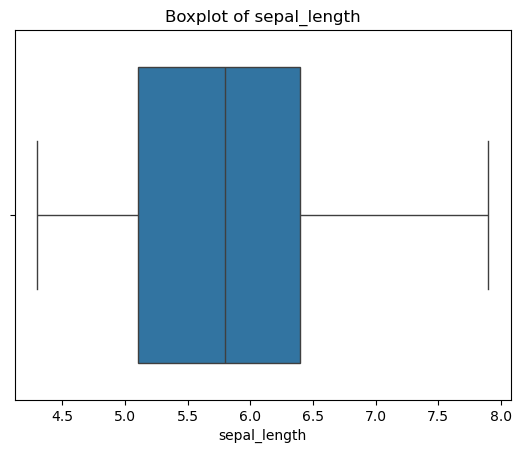

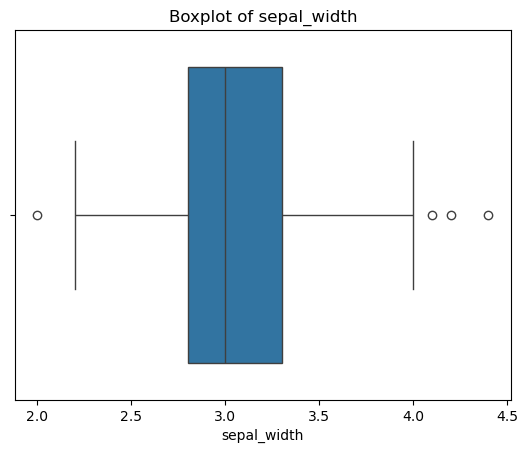

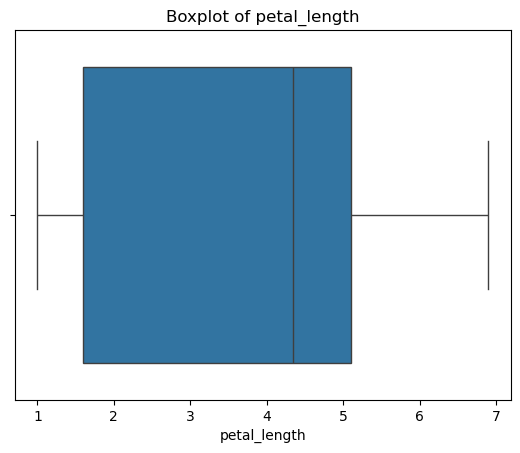

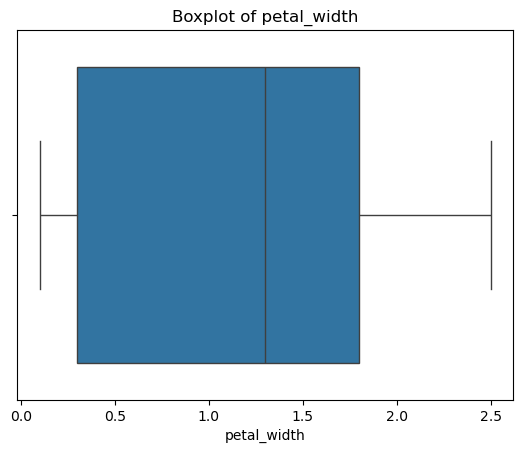

In [25]:
# check outliers for each column using boxplot
for column in iris.columns[:-1]:
    sns.boxplot(x=iris[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

In [26]:
# IQR method to remove outliers for sepal width
Q1 = iris['sepal_width'].quantile(0.25)
Q3 = iris['sepal_width'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Filter the dataset to remove outliers
iris_filtered = iris[(iris['sepal_width'] >= lower_bound) & (iris['sepal_width'] <= upper_bound)]
# Check the shape of the original and filtered datasets
print(f'Original dataset shape: {iris.shape}')

Original dataset shape: (150, 5)


In [27]:
x=iris.drop('species',axis=1)
y=iris['species']

In [28]:
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [29]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
# decision tree classifier
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier(criterion='entropy',max_depth=3,random_state=42)

In [32]:
model1.fit(x_train,y_train)
y_pred = model1.predict(x_test)

In [33]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
1.0


In [34]:
# check for test data
print(classification_report(y_train,model1.predict(x_train)))
print(confusion_matrix(y_train,model1.predict(x_train)))
print(accuracy_score(y_train,model1.predict(x_train)))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        40
  versicolor       0.91      0.98      0.94        41
   virginica       0.97      0.90      0.93        39

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120

[[40  0  0]
 [ 0 40  1]
 [ 0  4 35]]
0.9583333333333334


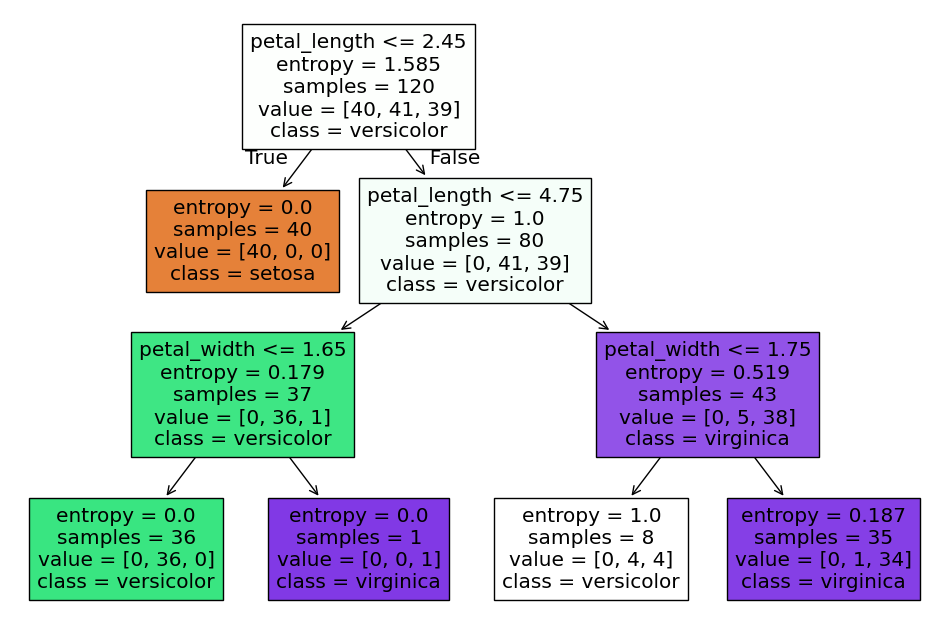

In [35]:
# make a decision tree visualization
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model1,feature_names=x.columns,class_names=model1.classes_,filled=True)
plt.show()

In [36]:
model2= DecisionTreeClassifier()
model2.fit(x_train,y_train)

DecisionTreeClassifier()

In [37]:
y_pred2 = model2.predict(x_test)
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(accuracy_score(y_test,y_pred2))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
1.0


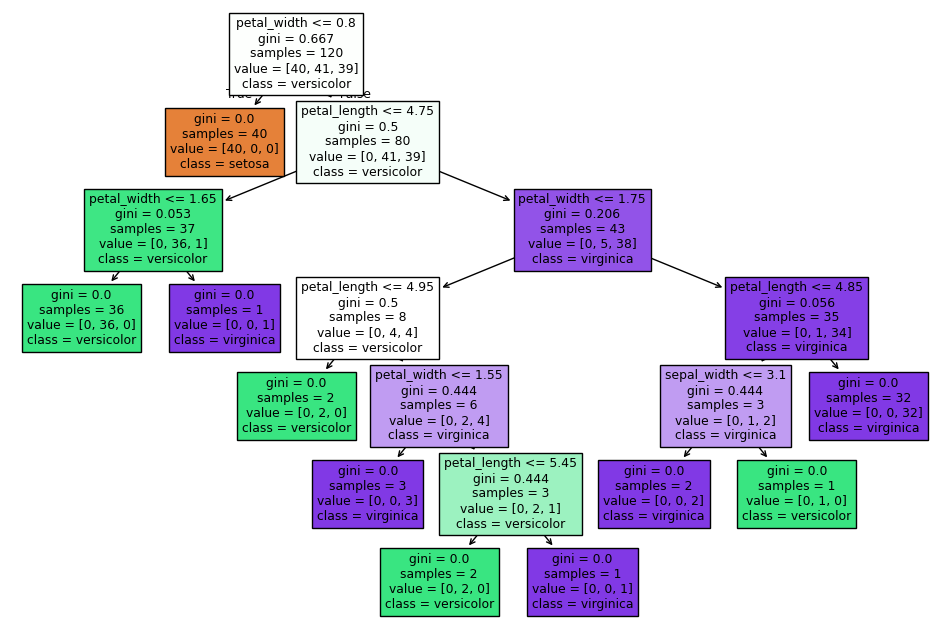

In [39]:
#plot the second tree
plt.figure(figsize=(12,8))
plot_tree(model2,feature_names=x.columns,class_names=model2.classes_,filled=True)
plt.show()

In [49]:
params={'criterion':['gini','entropy','log_loss'],'max_depth':[1,2,3,4,5,6],'splitter':['best','random'],'max_features':['auto','sqrt','log2']}

In [50]:
from sklearn.model_selection import GridSearchCV

In [51]:
treemodel= DecisionTreeClassifier()

In [52]:
grid=GridSearchCV(treemodel,param_grid=params,cv=5,scoring='accuracy')

In [53]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 6],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [54]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [55]:
grid.best_score_

0.9583333333333334

In [57]:
y_pred_grid = grid.predict(x_test)
print(classification_report(y_test,y_pred_grid))
print(confusion_matrix(y_test,y_pred_grid)) 
print(accuracy_score(y_test,y_pred_grid))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
1.0
